### 지도학습 절차

- 지도학습 : 목표변수(Y)와 설명변수(X)의 관계를 학습해서, 새로운 X가 들어올 때, Y를 예측 / 분류

- 지도학습의 절차 6단계:
  1. 데이터 핸들링 (데이터 불러오기 / 파생변수 생성 / 층별화) : 데이터 구조적인 관점에서 학습을 수행할 수 있는 데이터셋을 구성하는 과정

  2. 학습에 사용될 목표변수(Y)와 설명변수(X)를 설정
    - 유의사항 : 사용되는 X는 새로 들어올 데이터에 대한 값으로 지정 ex. 신규고객 이탈 예측을 할 때 구매횟수와 방문횟수를 넣으면 안 됨.

  3. 학습 데이터(Train Set)와 검증 데이터(Test Set)분할
    - 검증 데이터(Test Set)는 학습에 참여하지 않는다! (교차검증에서 Validation Set과는 다른 개념)

  4. 학습을 수행 (Modeling)
    - 특성공학 (결측값 처리 / Encoding / Scaling ...) -> Pipe Line을 이용해서
    - 학습 (알고리즘)

  5. 학습된 모델 평가
    - 학습 능력 평가
    - 일반화 능력 평가


In [74]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

- 사용한 데이터 (https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [3]:
# 데이터 불러오기
df1 = pd.read_csv('diabetes.csv')
print(df1.shape)
print(df1.info())
print(df1.head())
print(df1.tail())

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2         

In [4]:
# 환자의 건강 관련 정보를 입력했을 때, 당뇨병에 걸릴지 말지에 대한 판별 모델 생성
# 1) 데이터 핸들링
df1['Outcome'].unique()

array([1, 0])

In [5]:
df1["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

<Axes: xlabel='Outcome'>

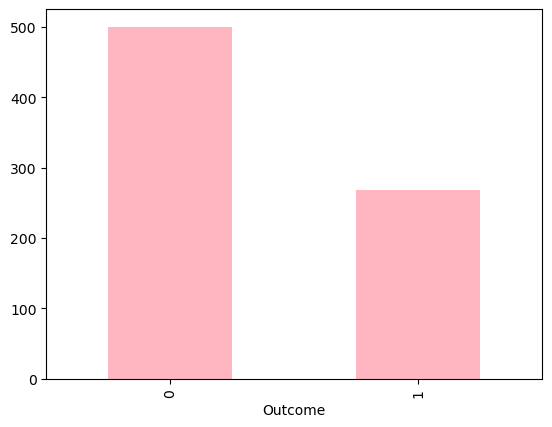

In [6]:
df1["Outcome"].value_counts().plot(kind="bar",color='lightpink')

## **결측치는 없지만 0이 나올 수 있는 변수와 아닌 변수를 구분해서 EDA 할 것**

## **Pregrance**
 - 임신횟수
 - 임신 경험이 없으면 0으로 나올 수 있기에 결측치가 아닌 정상값
 


In [7]:
df1["Pregnancies"].value_counts()

Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64

In [8]:
df1['Pregnancies'].describe()

count    768.000000
mean       3.845052
std        3.369578
min        0.000000
25%        1.000000
50%        3.000000
75%        6.000000
max       17.000000
Name: Pregnancies, dtype: float64

<Axes: xlabel='Pregnancies', ylabel='Count'>

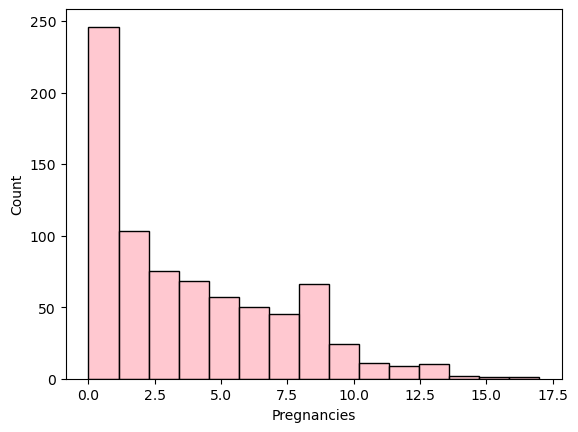

In [20]:
sns.histplot(df1['Pregnancies'], bins=15,color='lightpink')

<Axes: title={'center': 'Pregnancies'}, xlabel='Outcome'>

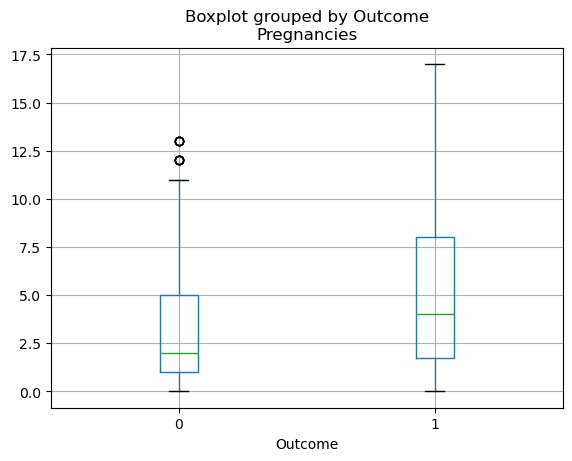

In [10]:
#당뇨 여부에 따라 임신 횟수의 분포와 중앙값에 차이가 나타남을 확인

df1.boxplot(column="Pregnancies", by="Outcome")

### **변수 인사이트 정리**

- Pregnancies 변수는 임신 횟수를 나타내는 이산형 수치 변수로, 0을 포함한 모든 값이 실제 의미를 갖는 관측값이다. 데이터 분포를 확인한 결과, 임신 횟수는 0~4회 구간에 대부분의 관측치가 집중되어 있으며, 10회 이상의 고임신 횟수는 극소수에 불과해 오른쪽으로 긴 꼬리를 가진 분포를 보였다. 이러한 분포 특성으로 인해 평균보다 중앙값을 중심으로 한 해석이 보다 적절하다고 판단하였다.

- 당뇨 발병 여부(Outcome)에 따라 Pregnancies 변수의 분포를 비교한 결과, 당뇨 환자 집단에서 임신 횟수의 평균과 중앙값이 비당뇨 집단보다 높게 나타나는 경향을 확인할 수 있었다. 이는 임신 경험이 많을수록 당뇨 발병과 관련된 위험 요인이 누적될 가능성을 시사한다.

## **glucose**
- 혈장 포도당 농도
- 사람 혈당이 0일 수는 없다.
- 당뇨는 혈당이 지속적으로 높은 증상

<Axes: xlabel='Glucose', ylabel='Count'>

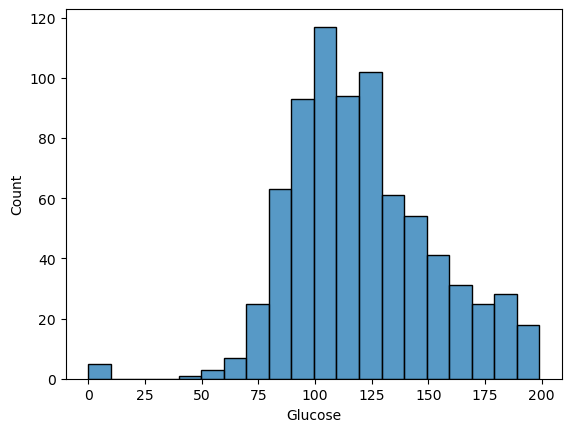

In [17]:
sns.histplot(df1['Glucose'], bins=20)

In [18]:
# Glucose에서 0값 개수 확인
(df1["Glucose"] == 0).sum()

np.int64(5)

In [19]:
#0값 비율도 확인
(df1["Glucose"] == 0).mean()

np.float64(0.006510416666666667)

In [20]:
#0을 결측치로 변환
df1["Glucose"] = df1["Glucose"].replace(0, np.nan)
df1["Glucose"].isnull().sum()

np.int64(5)

In [21]:
#결측치 중앙값으로 대체하고 확인(glucose변수는 이상치 영향이 있으므로)
glucose_median = df1['Glucose'].median()
df1['Glucose'] = df1['Glucose'].fillna(glucose_median)
df1["Glucose"].isnull().sum()

np.int64(0)

<Axes: xlabel='Glucose', ylabel='Count'>

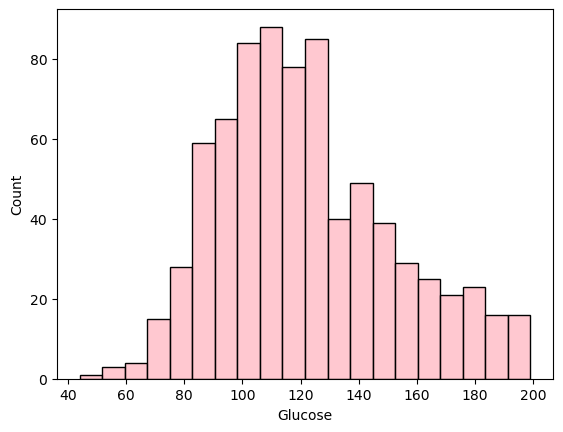

In [22]:
 sns.histplot(df1['Glucose'], bins=20,color='lightpink')

<Axes: title={'center': 'Glucose'}, xlabel='Outcome'>

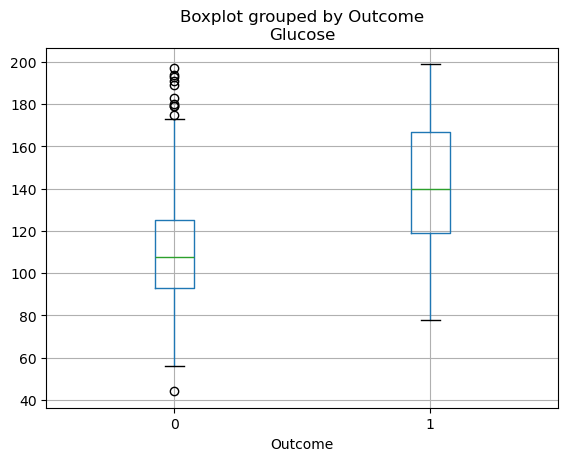

In [23]:
df1.boxplot(column="Glucose", by="Outcome")

### **변수 인사이트 정리**

- Glucose 변수는 공복 혈당 수치를 나타내는 연속형 변수로, 당뇨 발병 여부를 설명하는 데 가장 핵심적인 건강 지표 중 하나이다.
- 결측값은 5개, 전체에서 약 0.0065의 비율에 해당했고 이상치 영향을 고려하여 중앙값으로 대체하였다.
- 0값을 결측치(NaN)로 변환한 후 분포를 확인한 결과, Glucose값은 90~120 구간에 관측치가 집중되어 있으며 오른쪽으로 긴 꼬리를 가진 분포를 보였다.
- 당뇨 발병 여부에 따라 Glucose 분포를 비교한 결과, 당뇨 환자 집단에서 비당뇨 집단에 비해 전반적으로 혈당 수치가 높게 나타났다. 즉 Glucose 변수가 당뇨 발병 여부를 구분하는 데 있어 중요한 변수임을 알 수 있다.

## **bloodpressure**
- 혈압
- 혈압도 0일 수는 없다 

<Axes: xlabel='BloodPressure', ylabel='Count'>

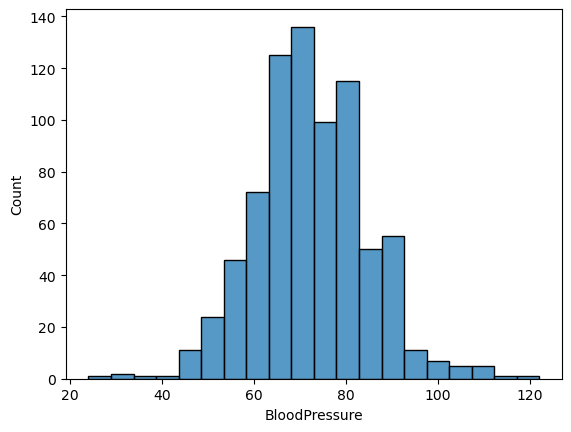

In [28]:
sns.histplot(df1['BloodPressure'], bins=20)

In [ ]:
# bloodpressure에서 0값 개수 확인
(df1['BloodPressure']==0).sum()

np.int64(35)

In [12]:
#0값 비율도 확인
(df1["BloodPressure"] == 0).mean()

np.float64(0.045572916666666664)

In [13]:
#0을 결측치로 변환
df1["BloodPressure"] = df1["BloodPressure"].replace(0, np.nan)
df1["BloodPressure"].isnull().sum()

np.int64(35)

In [15]:
#결측치 중앙값으로 대체하고 확인
bloodpressure_median = df1['BloodPressure'].median()
df1['BloodPressure'] = df1['BloodPressure'].fillna(bloodpressure_median)
df1["BloodPressure"].isnull().sum()

np.int64(0)

<Axes: xlabel='BloodPressure', ylabel='Count'>

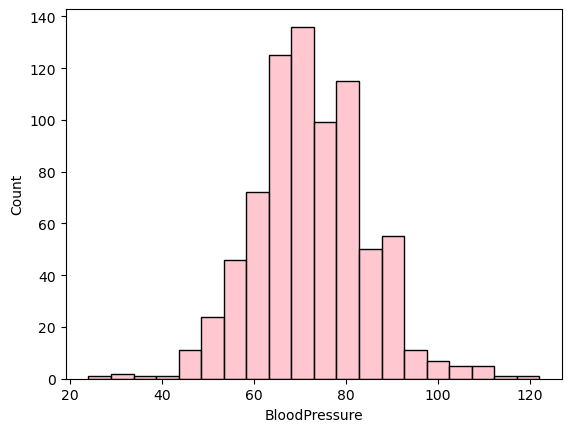

In [26]:
 sns.histplot(df1['BloodPressure'], bins=20,color='lightpink')

<Axes: title={'center': 'BloodPressure'}, xlabel='Outcome'>

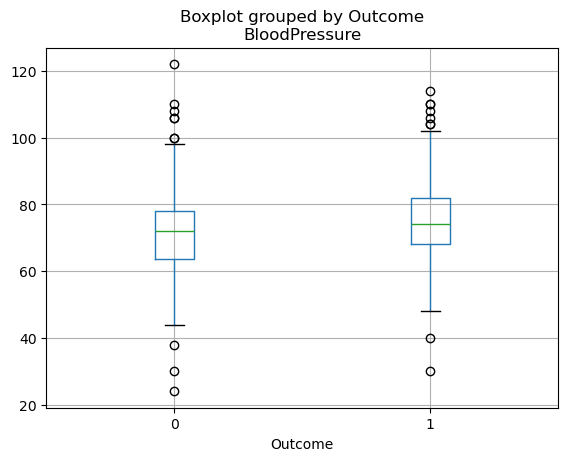

In [27]:
df1.boxplot(column="BloodPressure", by="Outcome")

### **변수 인사이트 정리**

- bloodpressure 변수도 glucose 변수처럼 0으로 존재할 수 없어 결측치로 판단하였다.
- 결측치는 중앙값으로 대체하였다.
- 분포 형태는 정규분포에 가까운 종형 분포
- 당뇨 그룹에서 100mmHg이상 고혈압 이상치가 더 자주 관찰되었기에 당뇨 환자에게서 고혈압이 동반될 가능성이 더 크게 있다.

## **SkinThickness**
- 삼두근 피부 두께
- 체지방이란 관련이 있다.
- 0일 수 없다
- 체지방을 대표하는 BMI를 기준으로 나눌 것이며, BMI를 구간화한 뒤 각 구간의 SkinThickness 중앙값으로 대체


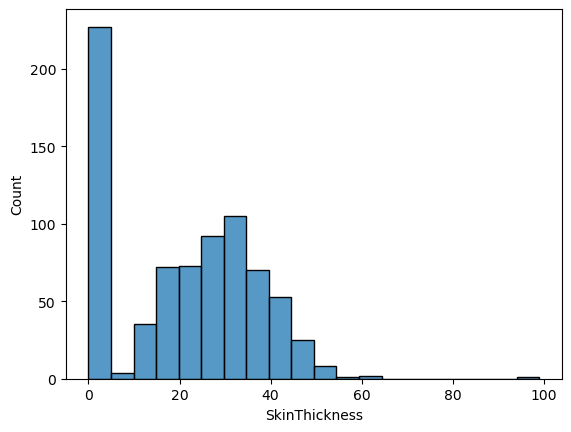

In [59]:
sns.histplot(df1['SkinThickness'], bins=20)
df1 = pd.read_csv('diabetes.csv')

In [60]:
# SkinThickness에서 0값 개수 확인
(df1['SkinThickness']==0).sum()

np.int64(227)

In [61]:
#0값 비율도 확인
(df1["SkinThickness"] == 0).mean()

np.float64(0.2955729166666667)

In [ ]:
#0을 결측치로 변환
df1['SkinThickness'] = df1['SkinThickness'].replace(0, np.nan)
df1['SkinThickness'].isna().sum()

np.int64(0)

In [69]:
#BMI구간화
df1['BMI_group'] = pd.cut(
    df1['BMI'],
    bins=[0, 18.5, 25, 30, float('inf')],
    labels=['저체중', '정상', '과체중', '비만']
)

In [70]:
#결측치 대체
df1['SkinThickness'] = df1['SkinThickness'].replace(0, pd.NA)

In [71]:
#BMI 구간별 중앙값 계산
bmi_median = df1.groupby('BMI_group')['SkinThickness'].median()

C:\Users\happi\AppData\Local\Temp\ipykernel_7372\3672179298.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_median = df1.groupby('BMI_group')['SkinThickness'].median()


In [72]:
#결측치 중앙값으로 대체하고 확인
df1['SkinThickness'] = df1['SkinThickness'].fillna(
    df1['BMI_group'].map(bmi_median)
)
df1['SkinThickness'].isna().sum()

np.int64(0)

<Axes: xlabel='SkinThickness', ylabel='Count'>

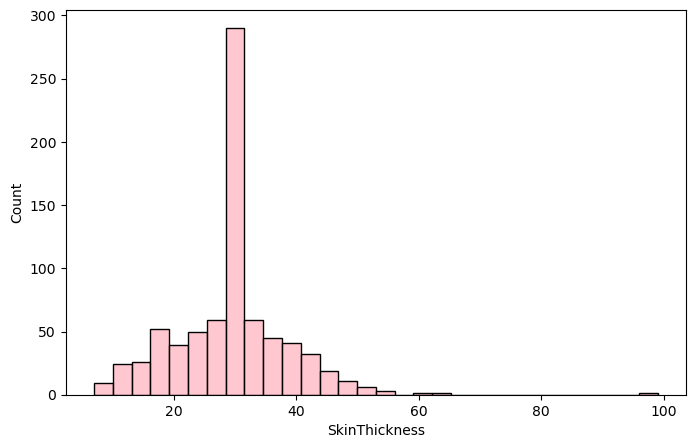

In [75]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df1['SkinThickness'],
    bins=30,
    color='lightpink'
)

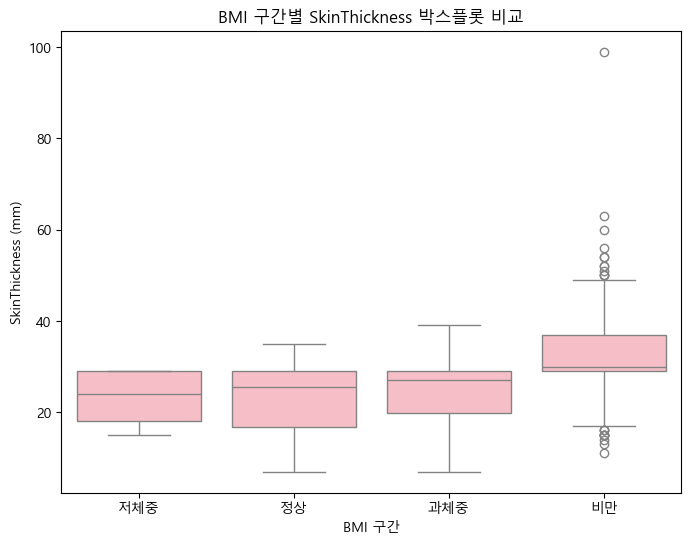

In [79]:

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df1,
    x='BMI_group',
    y='SkinThickness',
    order=['저체중', '정상', '과체중', '비만'],
    color='lightpink'
)

plt.xlabel('BMI 구간')
plt.ylabel('SkinThickness (mm)')
plt.title('BMI 구간별 SkinThickness 박스플롯 비교')

plt.show()

### **변수 인사이트 정리**

- 0값이 227개(약 30%)로 다량 존재
- skinthickness변수는 체지방량과 밀접한 관련이 있어 이를 대표하는 지표인 BMI지수에 따라 구분함
- skinThickness는 BMI 상승에 따라 증가(저체중에서 비만으로 갈수록 증가)

## **Insulin**
- 인슐린 분비량
- 당뇨병 유형은 인슐린이 선천적으로 나오지 않는 사람(1형)과 인슐린이 나오지만 인식을 못하는 사람(2형) 당뇨병 두가지가 있다.  
- 0이 이상치는 아닐 수도 있다. 
- 0은 결측치로 처리한다.

<Axes: xlabel='Insulin', ylabel='Count'>

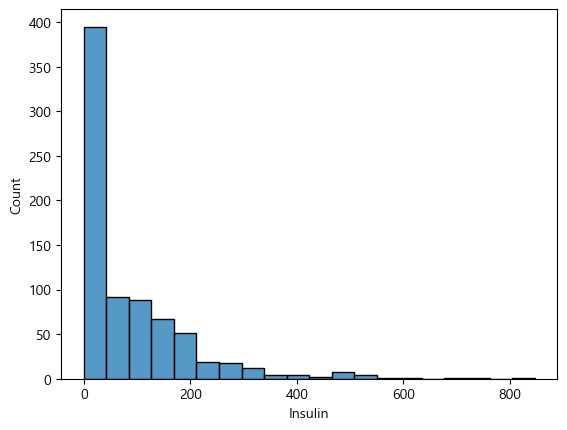

In [80]:
sns.histplot(df1['Insulin'], bins=20)

In [ ]:
# 0값 개수 확인
(df1['Insulin']==0).sum()

np.int64(374)

In [82]:
#0을 결측치로 변환
df1["Insulin"] = df1["Insulin"].replace(0, np.nan)
df1["Insulin"].isnull().sum()

np.int64(374)

In [83]:
#결측치 중앙값으로 대체하고 확인
Insulin_median = df1['Insulin'].median()
df1['Insulin'] = df1['Insulin'].fillna(Insulin_median)
df1['Insulin'].isnull().sum()

np.int64(0)

<Axes: xlabel='Insulin', ylabel='Count'>

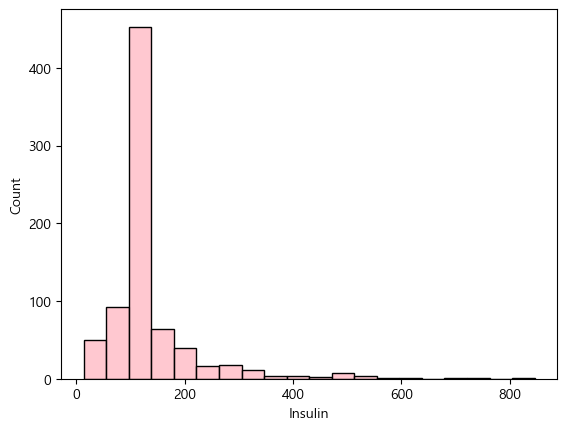

In [84]:
 sns.histplot(df1['Insulin'], bins=20,color='lightpink')

<Axes: title={'center': 'Insulin'}, xlabel='Outcome'>

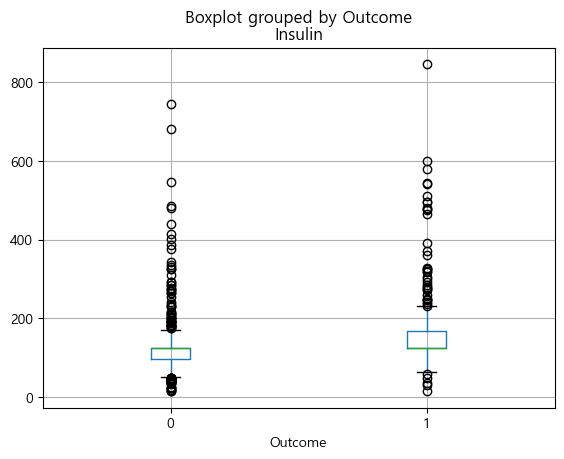

In [85]:
df1.boxplot(column="Insulin", by="Outcome")

### **변수 인사이트 정리**


- Insulin의 0값이 374개로 매우 많다.
- 초반에 강한 오른쪽 꼬리 모양의 분포를 가졌으나 결측치 대체 후 분포 왜곡이 줄어들었다.
- 당뇨 환자 그룹에서 인슐린 수치가 전반적으로 더 높은 것을 알 수 있다.


## **BMI**
- 0이 나올 수 없는 값

<Axes: xlabel='BMI', ylabel='Count'>

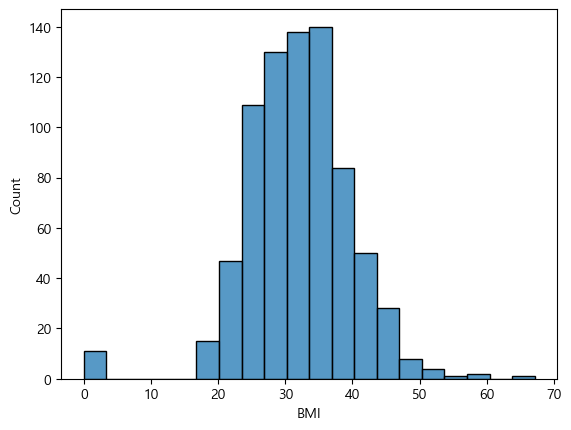

In [86]:
sns.histplot(df1['BMI'], bins=20)

In [87]:
# 0 개수 확인
(df1['BMI'] == 0).sum()

np.int64(11)

In [88]:
# 0을 결측치로 변환
df1['BMI'] = df1['BMI'].replace(0, np.nan)
df1['BMI'].isna().sum()

np.int64(11)

In [89]:
# 결측치 중앙값으로 대체하고 확인
bmi_median = df1['BMI'].median()
df1['BMI'] = df1['BMI'].fillna(bmi_median)
df1['BMI'].isna().sum()

np.int64(0)

<Axes: xlabel='BMI', ylabel='Count'>

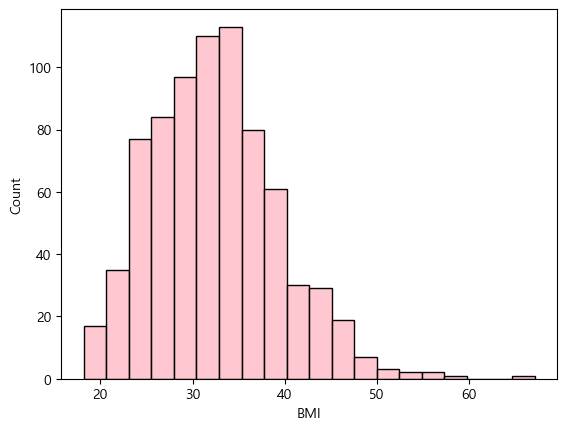

In [90]:
 sns.histplot(df1['BMI'], bins=20,color='lightpink')

<Axes: title={'center': 'BMI'}, xlabel='Outcome'>

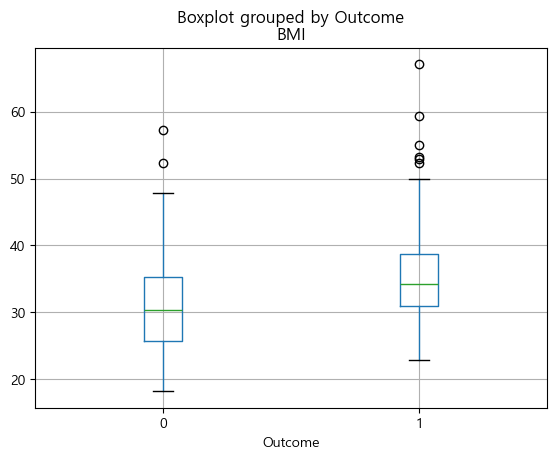

In [91]:
df1.boxplot(column="BMI", by="Outcome")

### **변수 인사이트 정리**

- 0값 결측치는 11 개 존재한다.
- 0으로 존재할 수 없기에 중앙값으로 대체하였다.
- 위의 skinthickness변수에서 보였듯이 BMI지수가 높아짐에 따라 당뇨병 위험이 높아질 수 있다. 

## **파생변수 생성 및 추가 전처리**

In [94]:
# Age 연령대 그룹화
df1['Age_group'] = pd.cut(
    df1['Age'],
    bins=[0, 20, 30, 40, 50, float('inf')],
    labels=['20세 미만', '20대', '30대', '40대', '50대 이상']
)
df1['Age_group'].value_counts().sort_index()

Age_group
20세 미만      0
20대       417
30대       157
40대       113
50대 이상     81
Name: count, dtype: int64

In [95]:
pd.crosstab(df1['Age_group'], df1['Outcome'])

Outcome,0,1
Age_group,,
20대,327,90
30대,81,76
40대,49,64
50대 이상,43,38


In [97]:
#연령대별 당뇨병 여부 결과
pd.crosstab(df1['Age_group'], df1['Outcome'])


Outcome,0,1
Age_group,,
20대,327,90
30대,81,76
40대,49,64
50대 이상,43,38


In [98]:
#비율로 확인
pd.crosstab(
    df1['Age_group'],
    df1['Outcome'],
    normalize='index'
) * 100


Outcome,0,1
Age_group,,
20대,78.417266,21.582734
30대,51.592357,48.407643
40대,43.362832,56.637168
50대 이상,53.086420,46.913580


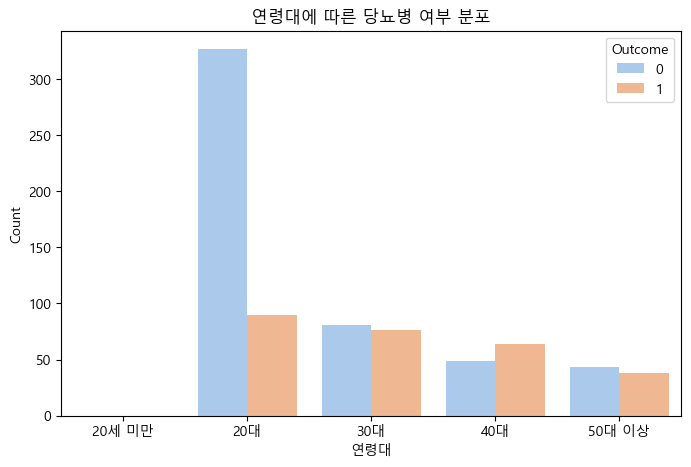

In [99]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df1,
    x='Age_group',
    hue='Outcome',
    order=['20세 미만', '20대', '30대', '40대', '50대 이상'],
    palette='pastel'
)

plt.xlabel('연령대')
plt.ylabel('Count')
plt.title('연령대에 따른 당뇨병 여부 분포')
plt.legend(title='Outcome')

plt.show()

- 연령대가 증가할수록 당뇨병(Outcome=1) 발생 비율이 뚜렷하게 증가한다.
- 연령 증가에 따라 인슐린 감소, 체지방 증가 등의 원인 존재

# **모델링하기**

In [100]:
# 2) 목표변수 / 설명변수 설정
# 파생 변수는 추가하고, 필요 없는 변수는 빼기

X = df1[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
Y = df1['Outcome'] # Y값에는 결측치가 존재해서는 안됨

In [101]:
# 3) 학습데이터와 검증데이터를 분할
# pip install scikit-learn
from sklearn.model_selection import train_test_split

In [6]:
train_test_split(X,Y) # X 데이터의 학습, 검증 데이터 & Y 데이터의 학습, 검증데이터 4개로 분리됨

[     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 466            0       74             52             10       36  27.8   
 187            1      128             98             41       58  32.0   
 207            5      162            104              0        0  37.7   
 178            5      143             78              0        0  45.0   
 632            2      111             60              0        0  26.2   
 ..           ...      ...            ...            ...      ...   ...   
 271            2      108             62             32       56  25.2   
 200            0      113             80             16        0  31.0   
 182            1        0             74             20       23  27.7   
 290            0       78             88             29       40  36.9   
 65             5       99             74             27        0  29.0   
 
      DiabetesPedigreeFunction  Age  
 466                     0.269   22  
 187                  

In [102]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=1234)
# train_test_split()에 별도의 옵션을 지정하지 않으면 75:25로 학습:검증 분할됨
# random_state을 지정해야 같은 결과가 나옴

In [11]:
X.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

=> X에도 결측치가 없는 데이터이지만, 추후 새로 들어올 데이터에 결측치가 존재할 수 있음

# **각자 공부한 모델 쓰기**

### RandomForest 모델 ###
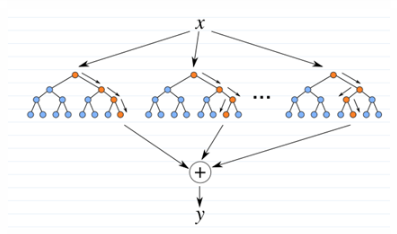
- 의사결정 나무에 배깅이라는 앙상블 학습을 적용한 모델!
- 의사결정 나무의 특징인 분산이 크다는 점을 고려하여 많은 무작위성을 주어 약한 학습기들을 생성한 후 이를 선형 결합하여 최종 학습기를 만드는 방법
- random input에 따른 forest of trees를 이용한 분류 방법이다.
- 여러 개의 의사 결정 트리 구축->각각의 개별 트리가 예측한 값을 모아서 다수결 vote->최종 예측 



1. RandomForest 모델의 특징
- 랜덤한 forest에는 많은 트리들이 생성된다.
- 수천 개의 변수를 통해 변수제거 없이 실행되므로 정확도 측면에서 좋은 성과를 보인다.
- 특히 입력변수가 많은 경우 좋은 에측력을 보인다.


1-1. 장점
- 높은 accuracy : 앙상블 방법 중 하나이기에 전반적으로 높은 정확도를 가진다.
- 과적합 방지 : 단일 decision tree가 가지던 과적합성을 완화할 수 있다. 이는 데이터를 bootstrapping하고 각 트리는 데이터의 속성을 랜덤하게 추출하면서 자연스럽게 노이즈나 outlier가 모델이 미치는 영향을 감소하는 효과를 가진다.


1-2. 단점
- high cost: 랜덤포레스트는 트리의 개수를 너무 많게 설정하고 데이터가 방대하면 모델 학습에 너무 많은 시간이 걸림
- 해석의 어려움 : 여러 개의 decision tree가 모여 만든 모델로 어떻게 예측을 수행하는지 한눈에 직관적으로 알아보고 해석하는 데 어려움을 겪을 수 있다.




" 과적합을 해소하고 분산을 감소시켜 정확도가 높다는 장점이 있지만, 계산 비용이 높고 규칙이 많아 추론 로직을 설명하기 어렵다는 단점이 있다. "




In [103]:
# 4) 학습 수행
from sklearn.ensemble import RandomForestClassifier

In [105]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, Y_train) # randomForest 학습 수행

RandomForestClassifier(random_state=42)

In [106]:
# 5) 성능 확인
from sklearn.metrics import accuracy_score
# 정확도 : 전체 데이터 중 얼만큼 정확히 분류했는지 비율

In [107]:
Y_train_pred = model.predict(X_train)

In [108]:
Y_test_pred = model.predict(X_test)

In [109]:
print('학습 정확도 : ', accuracy_score(Y_train, Y_train_pred)) # 여러 알고리즘에 대한 모델을 비교할 때 확인해야 함
print('검증 정확도 : ', accuracy_score(Y_test, Y_test_pred))

학습 정확도 :  1.0
검증 정확도 :  0.7760416666666666


### 과적합(Overfitting)

- 과적합 : 학습 데이터에 대해서는 Model이 높은 성능을 나타내지만, 검증데이터에서는 성능이 낮게 나오는 현상
- 해결 : 특성공학을 통해 데이터를 더 깔끔하게 생성

### 특성공학(Feature Engineering)
- **특성공학** : 학습의 목적에 맞게(학습이 잘 수행될 수 있도록) 데이터를 깔끔하게 다듬는 작업
- 대표적 기법 : 
  1. Scaling & Encoding : 숫자 데이터의 스케일을 맞추거나, 문자 데이터를 숫자로 변환하여 학습에 사용
  2. Imputation : 데이터 상에 존재하는 결측값에 대해 다른 값으로 대치 (새로 들어오는 데이터가 결측일 수도 있기 때문에)
  3. Cross Validation (교차검증): 학습데이터를 여러 단계로 나누어 분할하여 학습
  4. Hyper Parameter Tuning : 학습 알고리즘 내 존재하는 수학적 구조나 학습에 발생하는 구조, 함수들을 사용자가 통제
  5. Imbalanced Data Sampling : 목표변수의 비율이 깨져있는 데이터를 맞추어 학습
  6. Feature Selection : 목표변수에 가장 영향이 있는 인자를 사용자가 지정한 만큼 선택해서 학습
  7. PCA : 데이터의 차원을 줄이거나 특성을 재구성하여 학습

- Scikit Learn에서 특성공학 기법과 학습을 동시에 수행할 수 있게 Pipe Line 구성하여 학습을 수행

In [110]:
# 4) 학습 수행
from sklearn.pipeline import make_pipeline # 특성공학 + 학습
from sklearn.impute import SimpleImputer # 결측값 단순 대치 기법
from sklearn.tree import DecisionTreeClassifier # 학습 알고리즘(의사결정나무)
from sklearn.preprocessing import StandardScaler #Standard Scaling

In [119]:
# 파이프라인 구조 설계
#스케일링 하고 싶으면 StandardScaler() 사용

model_pipe = make_pipeline( RandomForestClassifier(n_estimators=100, random_state=42) )
model_pipe

Pipeline(steps=[('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [120]:
from sklearn.model_selection import GridSearchCV

#### **공부한 모델의 하이퍼파라미터**

2. 하이퍼 파라미터
2-1. n_estimators
 - 생성할 트리의 개수
 - 일반적으로 더 많은 트리를 사용할수록 모델의 성능이 향상 
 - 트리 개수가 일정 수준을 넘어서면 성능 향상의 폭이 급격히 줄어들면서 계산 비용만 증가하는 현상이 나타난다. - 실제 프로젝트에서는 성능과 효율성의 균형점을 찾는 것이 중요하며, 보통 100에서 1000 사이의 값을 실험해보는 것이 좋음



2-2. max_feature
- 각 노드를 분할할 때 고려할 특성의 무작위로 선택되는 특성의 개수
- 회귀: {“sqrt”, “log2”, None}, int or float, default=1.0 (전체 특성 수)
- 분류:{“sqrt”, “log2”, None}, int or float, default="sqrt" (전체 특성 수의 제곱근)
- 값을 작게 설정하면 분산 감소, 편향 증가, 복잡도 감소, 모델 성능 감소
- 값을 크게 설정하면 분산 증가, 편향 감소, 복잡도 증가, 모델 성능 증가, 과적합 위험


2.3. max_depth
- 트리의 최대 깊이
- 개별 트리의 최대 깊이를 제한하여 과적합 방지
- 기본값은 none으로 트리가 완전히 성장할 때까지 분할을 계쏙한다는 의미
- 일반적으로 5~20 사이의 값을 실험, 교차 검증을 통해 최적합 찾기


2-4. min_samples_split: 노드를 분할하기 위해 필요한 최소한의 샘플 개수 지정
- 기본값은 2이며, 이 값을 증가시키면 트리가 더 보수적으로 분할되어 과적합을 방지할 수 있다.
- 작은 값으로 설정하면 트리가 더 세밀하게 분할되어 복잡한 패턴을 학습할 수 있지만, 노이즈에 민감해질 수 있다.
- 데이터셋의 크기와 노이즈 수준을 고려하여 적절한 값을 선택해야 한다.


2-5. min_samples_leaf: 노드를 분할하기 위해 리프 노드가 가져야 할 최소한의 샘플 개수 제한
- 기본값은 1이지만, 이를 증가시키면 모델이 더 일반화된 예측을 하게 된다.
- 특히 노이즈가 많은 데이터에서는 이 값을 2 이상으로 설정하는 것이 도움이 될 수 있음


2-6. max_leaf_nodes: 생성될 수 있는 최대 리프 노드의 개수를 제한 
- 일반적으로 랜덤 포레스트의 트리는 자라다가 가능한 한 많은 리프 노드를 생성하려는 경향이 있다. 
- 그러나 max_leaf_nodes를 설정함으로써 트리의 성장을 제한할 수 있다.
- max_leaf_nodes를 지정하면 트리는 해당 개수 이상의 리프 노드를 생성하지 않는다. 
- 이를 통해 과적합을 방지하고, 일반화 능력을 향상시킬 수 있니다.
- 작은 max_leaf_nodes 값은 모델의 단순성을 증가시키고 편향을 높일 수 있다.


2-7. .bootstrap: 부트스트래핑은 중복을 허용하여 샘플을 랜덤 하게 선택하는 방식, 모델의 다양성을 증가
- 부트스트랩 샘플링의 사용 여부를 결정한다. 
- 기본값은 True이며, 이는 각 트리가 원본 데이터에서 중복을 허용하여 무작위로 선택된 샘플로 학습된다는 의미, 이러한 무작위성은 개별 트리 간의 다양성을 증가시켜 앙상블 효과를 극대화
 키우면 극단적인 분기를 방지하고 일반화 성능이 올라간다.



In [ ]:
# 하이퍼파라미터 튜닝 및 교차검증
model = RandomForestClassifier(random_state=42)
hyperparam =  {
    'randomforestclassifier__n_estimators': [100, 200, 500],      # 트리 개수
    'randomforestclassifier__max_depth': [None, 5, 10],           # 트리 최대 깊이(과적합 조절)
    'randomforestclassifier__min_samples_split': [2, 5, 10],      # 분기 최소 샘플 수
    'randomforestclassifier__min_samples_leaf': [1, 2, 4],        # 리프 최소 샘플 수
    'randomforestclassifier__max_features': ['sqrt', 'log2'],     # 분기 시 사용할 변수 수 방식
    'randomforestclassifier__class_weight': [None, 'balanced']   # 클래스 불균형 보정
}

grid_model1 = GridSearchCV(model_pipe, param_grid = hyperparam, cv=3,
                          scoring='f1', n_jobs=-1)
grid_model1.fit(X_train, Y_train)
best_model1 = grid_model1.best_estimator_

In [ ]:
best_model1

In [27]:
# 5) 평가
Y_train_pred = best_model1.predict(X_train) # 학습 데이터의 예측값 계산
Y_test_pred = best_model1.predict(X_test) # 검증데이터의 예측값 계산

In [18]:
from sklearn.metrics import classification_report

In [29]:
# 학습 성능 평가
print(classification_report(Y_train, Y_train_pred))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       379
           1       0.81      0.75      0.78       197

    accuracy                           0.85       576
   macro avg       0.84      0.83      0.83       576
weighted avg       0.85      0.85      0.85       576



In [30]:
# 일반화 성능 평가
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.76      0.80      0.78       121
           1       0.62      0.56      0.59        71

    accuracy                           0.71       192
   macro avg       0.69      0.68      0.69       192
weighted avg       0.71      0.71      0.71       192



# **성능을 높이기 위한 방안**

1. test 데이터의 정확도가 test 데이터의 정확도보다 많이 낮으면 과적합
2. 하이퍼파라미터 튜닝, 추가적인 전처리(변수 제거) 혹은 파생변수 생성 으로 이를 해결 할 수 있다.  